# Formula 1 Tyre Degradation Analysis

By Sami Krothapalli

## Step 1: Import Dataset

AeroSpeed F1 Telemetry Car Aero 2022-2024
Dataset Link:  https://www.kaggle.com/datasets/shivmahlan/aerospeed-analytics?utm_source=chatgpt.com


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_folder = "data/F1 Dataset"

os.listdir(data_folder)

laps = pd.read_csv("data/F1 Dataset/f1_race_laps.csv")
laps.head()
print(laps.shape)
laps.columns

(73398, 24)


Index(['Driver', 'DriverNumber', 'Team', 'LapTime', 'LapNumber', 'Compound',
       'TyreLife', 'FreshTyre', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
       'Sector1Time', 'Sector2Time', 'Sector3Time', 'PitInTime', 'PitOutTime',
       'TrackStatus', 'IsAccurate', 'GP', 'Location', 'Year', 'Round',
       'HasPitStop'],
      dtype='object')

## Step 2: Clean Dataset
Want to keep only normal dry racing laps

In [14]:
clean_laps = laps.copy()
clean_laps = clean_laps[
    (clean_laps["IsAccurate"] == True) &
    (clean_laps["HasPitStop"] == False) &
    (clean_laps["PitInTime"].isna()) &
    (clean_laps["TrackStatus"] == 1) &
    (clean_laps["Compound"].isin(["SOFT", "MEDIUM", "HARD"])) &
    (clean_laps["LapTime"].notna()) &
    (clean_laps["TyreLife"].notna())
]
print(clean_laps.shape)
clean_laps.head()

(58521, 24)


,Driver,DriverNumber,Team,LapTime,LapNumber,Compound,TyreLife,FreshTyre,SpeedI1,SpeedI2,...,Sector3Time,PitInTime,PitOutTime,TrackStatus,IsAccurate,GP,Location,Year,Round,HasPitStop
1,VER,1,Red Bull Racing,97.880,2.0,SOFT,5.0,False,230.0,252.0,...,24.326,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
2,VER,1,Red Bull Racing,98.357,3.0,SOFT,6.0,False,229.0,254.0,...,24.384,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
3,VER,1,Red Bull Racing,98.566,4.0,SOFT,7.0,False,231.0,250.0,...,24.550,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
4,VER,1,Red Bull Racing,98.877,5.0,SOFT,8.0,False,229.0,256.0,...,24.525,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False
5,VER,1,Red Bull Racing,98.940,6.0,SOFT,9.0,False,229.0,255.0,...,24.609,NaN,NaN,1,True,Bahrain Grand Prix,Sakhir,2022,1,False


## Step 3: Create Stints 
    Sting -> Continuous Run on Same set of tires

In [15]:
clean_laps = clean_laps.sort_values(
    ["Year", "Round", "Driver", "LapNumber"]
).copy()

clean_laps["NewStint"] = (
    (clean_laps["Compound"] != clean_laps.groupby(["Year", "Round", "Driver"])["Compound"].shift()) |
    (clean_laps["TyreLife"] < clean_laps.groupby(["Year", "Round", "Driver"])["TyreLife"].shift())
)

clean_laps["Stint"] = clean_laps.groupby(["Year", "Round", "Driver"])["NewStint"].cumsum()

clean_laps[["Year", "GP", "Driver", "LapNumber", "Compound", "TyreLife", "Stint", "LapTime"]].head(20)

,Year,GP,Driver,LapNumber,Compound,TyreLife,Stint,LapTime
437,2022,Bahrain Grand Prix,ALB,2.0,SOFT,2.0,1,100.548
438,2022,Bahrain Grand Prix,ALB,3.0,SOFT,3.0,1,100.664
439,2022,Bahrain Grand Prix,ALB,4.0,SOFT,4.0,1,101.126
440,2022,Bahrain Grand Prix,ALB,5.0,SOFT,5.0,1,102.303
441,2022,Bahrain Grand Prix,ALB,6.0,SOFT,6.0,1,101.708
442,2022,Bahrain Grand Prix,ALB,7.0,SOFT,7.0,1,101.561
443,2022,Bahrain Grand Prix,ALB,8.0,SOFT,8.0,1,103.097
444,2022,Bahrain Grand Prix,ALB,9.0,SOFT,9.0,1,102.149
445,2022,Bahrain Grand Prix,ALB,10.0,SOFT,10.0,1,103.500
446,2022,Bahrain Grand Prix,ALB,11.0,SOFT,11.0,1,102.588


## Step 3: Create PaceDelta
~ Compare each lap to drivers best pace in the same stint

In [16]:
reference_pace = (
    clean_laps
    .groupby(["Year", "Round", "Driver", "Stint"])["LapTime"]
    .transform("min")
)

clean_laps["PaceDelta"] = clean_laps["LapTime"] - reference_pace

clean_laps[["Driver", "GP", "LapNumber", "Compound", "TyreLife", "LapTime", "PaceDelta"]].head(20)

,Driver,GP,LapNumber,Compound,TyreLife,LapTime,PaceDelta
437,ALB,Bahrain Grand Prix,2.0,SOFT,2.0,100.548,0.000
438,ALB,Bahrain Grand Prix,3.0,SOFT,3.0,100.664,0.116
439,ALB,Bahrain Grand Prix,4.0,SOFT,4.0,101.126,0.578
440,ALB,Bahrain Grand Prix,5.0,SOFT,5.0,102.303,1.755
441,ALB,Bahrain Grand Prix,6.0,SOFT,6.0,101.708,1.160
442,ALB,Bahrain Grand Prix,7.0,SOFT,7.0,101.561,1.013
443,ALB,Bahrain Grand Prix,8.0,SOFT,8.0,103.097,2.549
444,ALB,Bahrain Grand Prix,9.0,SOFT,9.0,102.149,1.601
445,ALB,Bahrain Grand Prix,10.0,SOFT,10.0,103.500,2.952
446,ALB,Bahrain Grand Prix,11.0,SOFT,11.0,102.588,2.040


# Step 4: Check Data Reliabillity

In [28]:
# Count how many laps we have
tyre_life_counts = (
    clean_laps
    .groupby(["Compound", "TyreLife"])
    .size()
    .reset_index(name="LapCount")
)
tyre_life_counts.head()

,Compound,TyreLife,LapCount
0,HARD,2.0,852
1,HARD,3.0,1020
2,HARD,4.0,1011
3,HARD,5.0,1061
4,HARD,6.0,1082


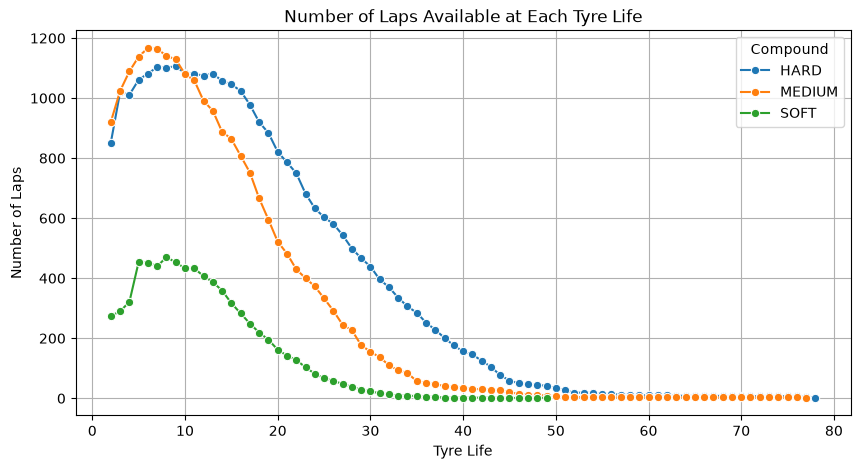

In [29]:
# Plot Lap Counts
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=tyre_life_counts,
    x="TyreLife",
    y="LapCount",
    hue="Compound",
    marker="o"
)

plt.title("Number of Laps Available at Each Tyre Life")
plt.xlabel("Tyre Life")
plt.ylabel("Number of Laps")
plt.grid(True)
plt.show()

Notes:
- Hard Tires have lot of laps for longer tire ages
- Meduims have lots of laps for medum length stints
- Softs have fewer laps as teams don't kepp softs for very long


Solution:

- Before interpreting tyre degradation patterns, we examined the number of laps available at each tyre age. The number of observations declined sharply at higher tyre ages, especially for soft and medium tyres. Therefore, later tyre-life values were treated cautiously, and the main degradation plot was filtered to retain tyre-age values with sufficient observations.

# Filter for Tire Ages with Insuffiecent Data
- We Plot the median  as its less affected by strange or extreme laps


In [58]:
reliable_points = tyre_life_counts[tyre_life_counts["LapCount"] >= 30]

clean_laps_reliable = clean_laps.merge(
    reliable_points[["Compound", "TyreLife"]],
    on=["Compound", "TyreLife"],
    how="inner"
)

print(clean_laps.shape)
print(clean_laps_reliable.shape)

(58521, 27)
(57891, 27)


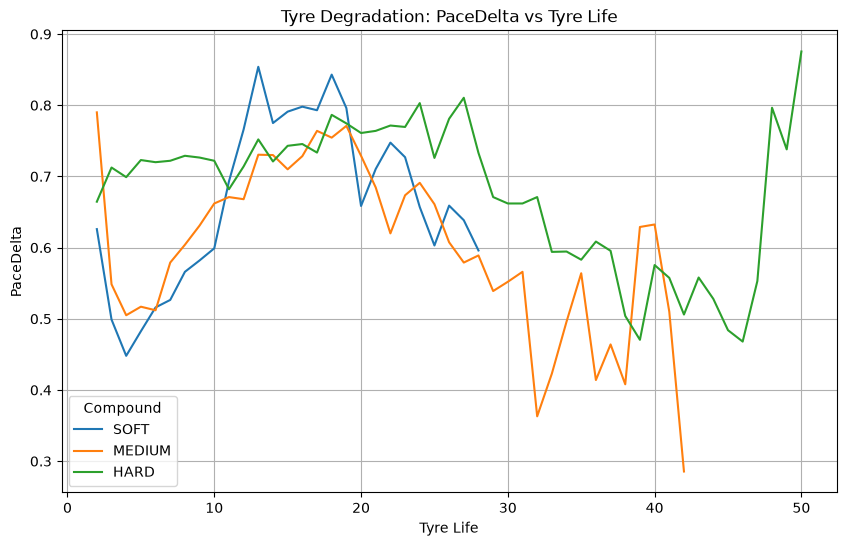

In [59]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=clean_laps_reliable,
    x="TyreLife",
    y="PaceDelta",
    hue="Compound",
    estimator="median",
    errorbar=None
)

plt.title("Tyre Degradation: PaceDelta vs Tyre Life")
plt.xlabel("Tyre Life")
plt.ylabel("PaceDelta")
plt.grid(True)
plt.show()

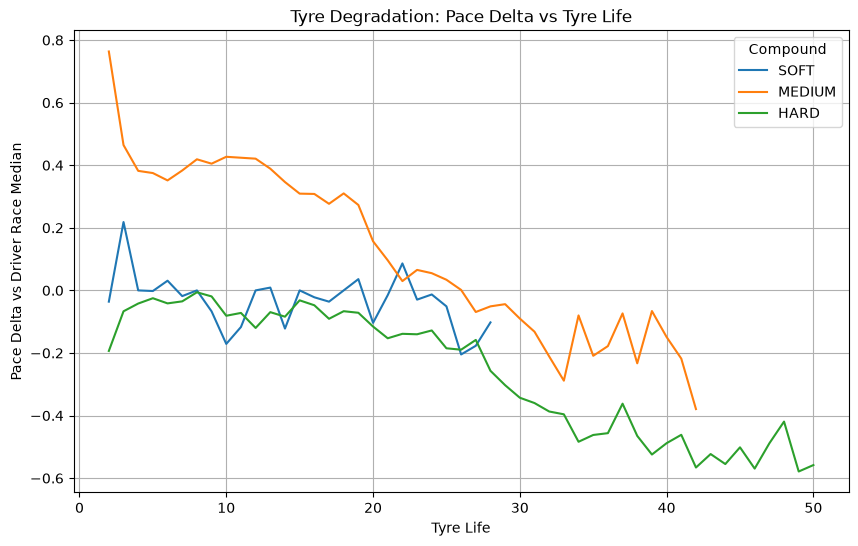

In [60]:
clean_laps_reliable = clean_laps_reliable.sort_values(
    ["Year", "Round", "Driver", "LapNumber"]
).copy()

# Use each driver's median clean lap time in the race as their reference pace
driver_race_reference = (
    clean_laps_reliable
    .groupby(["Year", "Round", "Driver"])["LapTime"]
    .transform("median")
)

clean_laps_reliable["PaceDelta_RaceMedian"] = (
    clean_laps_reliable["LapTime"] - driver_race_reference
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=clean_laps_reliable,
    x="TyreLife",
    y="PaceDelta_RaceMedian",
    hue="Compound",
    estimator="median",
    errorbar=None
)

plt.title("Tyre Degradation: Pace Delta vs Tyre Life")
plt.xlabel("Tyre Life")
plt.ylabel("Pace Delta vs Driver Race Median")
plt.grid(True)
plt.show()


- Need to create a new PaceDelta that adjusts for fuel burn
- So we predict lap time using race lap number, driver, race and year Then it keeps the leftover part which is our adjusted PaceDelta

In [61]:
import statsmodels.formula.api as smf

fuel_model = smf.ols(
    "LapTime ~ LapNumber + C(Driver) + C(GP) + C(Year)",
    data=clean_laps_reliable
).fit()

clean_laps_reliable["PaceDelta_Adjusted"] = fuel_model.resid

clean_laps_reliable[["LapTime", "LapNumber", "TyreLife", "Compound", "PaceDelta_Adjusted"]].head()

,LapTime,LapNumber,TyreLife,Compound,PaceDelta_Adjusted
0,100.548,2.0,2.0,SOFT,-0.478788
1,100.664,3.0,3.0,SOFT,-0.321255
2,101.126,4.0,4.0,SOFT,0.182277
3,102.303,5.0,5.0,SOFT,1.400809
4,101.708,6.0,6.0,SOFT,0.847342


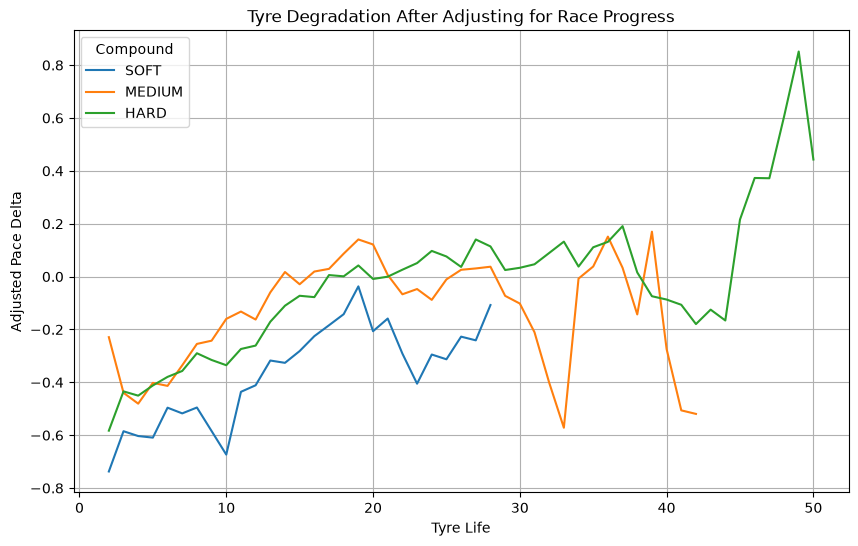

In [62]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=clean_laps_reliable,
    x="TyreLife",
    y="PaceDelta_Adjusted",
    hue="Compound",
    estimator="median",
    errorbar=None
)

plt.title("Tyre Degradation After Adjusting for Race Progress")
plt.xlabel("Tyre Life")
plt.ylabel("Adjusted Pace Delta")
plt.grid(True)
plt.show()

- Negative Adjusted Pace Delta = faster than expected 

- Positive Adjusted Pace Delta = slower than expected

# Step 5: Adding Spline

In [63]:
from patsy import bs
import statsmodels.formula.api as smf

spline_model = smf.ols(
    "PaceDelta_Adjusted ~ bs(TyreLife, df=6) + C(Compound)",
    data=clean_laps_reliable
).fit()

print(spline_model.summary())

                            OLS Regression Results                            
Dep. Variable:     PaceDelta_Adjusted   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     62.63
Date:                Sat, 15 Aug 2026   Prob (F-statistic):          1.23e-102
Time:                        18:40:08   Log-Likelihood:            -1.2807e+05
No. Observations:               57891   AIC:                         2.562e+05
Df Residuals:                   57882   BIC:                         2.562e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.25

In [64]:
prediction_data = pd.DataFrame({
    "TyreLife": list(range(2, 51)) * 3,
    "Compound": ["SOFT"] * 49 + ["MEDIUM"] * 49 + ["HARD"] * 49
})

prediction_data["SplinePrediction"] = spline_model.predict(prediction_data)

prediction_data.head()

,TyreLife,Compound,SplinePrediction
0,2,SOFT,0.640473
1,3,SOFT,0.259211
2,4,SOFT,0.052788
3,5,SOFT,-0.024702
4,6,SOFT,-0.019160


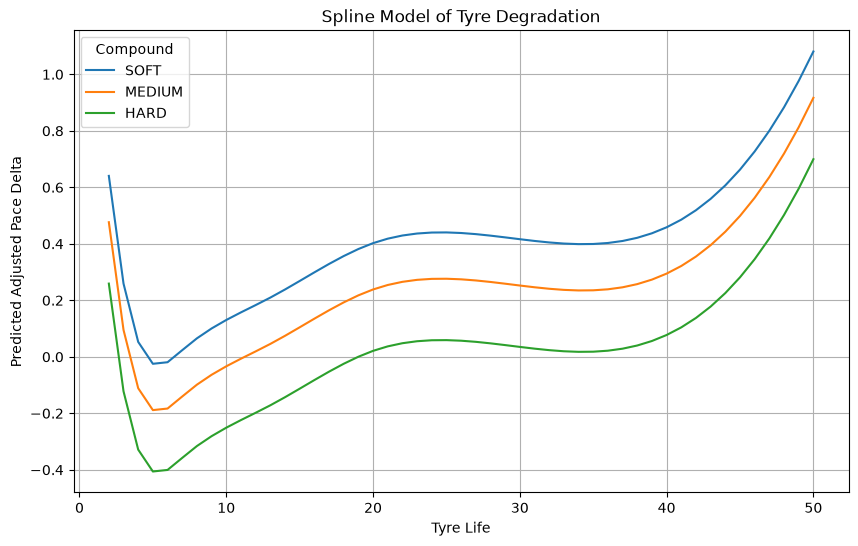

In [57]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=prediction_data,
    x="TyreLife",
    y="SplinePrediction",
    hue="Compound"
)

plt.title("Spline Model of Tyre Degradation")
plt.xlabel("Tyre Life")
plt.ylabel("Predicted Adjusted Pace Delta")
plt.grid(True)
plt.show()

The spline model shows an initial improvement in pace during the first few tyre laps, likely due to tyre warm-up, followed by a gradual increase in adjusted pace delta as tyre age increases. Soft tyres showed the largest predicted pace loss, while hard tyres showed the smallest. The sharp increase at high tyre ages suggests possible late-stint degradation, although this region should be interpreted cautiously because fewer observations are available at high tyre ages.